In [1]:
# You are part of an international NGO assessing whether access to improved sanitation facilities has increased after a 6-month intervention.
#You surveyed 100 people in each of 10 countries before and after the project. 
#Your goal is to use Bayesian methods and Monte Carlo simulation to evaluate success across countries.

In [2]:
#Step 1 – Load and Explore the Data

data <- read.csv("sdg6_sanitation_pre_post.csv")
head(data)


,Country,Pre_Improved_Sanitation,Post_Improved_Sanitation,Sample_Size
,<chr>,<int>,<int>,<int>
1,Kenya,56,70,100
2,Uganda,53,69,100
3,Tanzania,61,69,100
4,Rwanda,63,75,100
5,Ethiopia,47,65,100
6,Nepal,53,67,100


In [3]:
#Rows showed:
#Pre_Improved_Sanitation: Number of people reporting improved sanitation before
#Post_Improved_Sanitation: Number after the intervention
#Sample_Size: Always 100 in this dataset

In [4]:
#Step 2 – Define Prior Beliefs
#Assume a neutral belief: Beta(5, 5), meaning we think pre/post probabilities are likely around 50% but with uncertainty.

alpha_prior <- 5
beta_prior <- 5


In [5]:
#Step 3 – Calculate Posterior for Each Country

data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation
data$Post_Beta <- beta_prior + (data$Sample_Size - data$Post_Improved_Sanitation)

print(data)

      Country Pre_Improved_Sanitation Post_Improved_Sanitation Sample_Size
1       Kenya                      56                       70         100
2      Uganda                      53                       69         100
3    Tanzania                      61                       69         100
4      Rwanda                      63                       75         100
5    Ethiopia                      47                       65         100
6       Nepal                      53                       67         100
7  Bangladesh                      54                       71         100
8    Cambodia                      49                       75         100
9       Haiti                      56                       70         100
10  Guatemala                      52                       68         100
   Post_Alpha Post_Beta
1          75        35
2          74        36
3          74        36
4          80        30
5          70        40
6          72        38
7      

In [6]:
#Try repeating this for pre-intervention data to compare improvements.
data$Post_Alpha_2 <- alpha_prior + data$Pre_Improved_Sanitation
data$Post_Beta_2 <- beta_prior + (data$Sample_Size - data$Pre_Improved_Sanitation)

print(data)

      Country Pre_Improved_Sanitation Post_Improved_Sanitation Sample_Size
1       Kenya                      56                       70         100
2      Uganda                      53                       69         100
3    Tanzania                      61                       69         100
4      Rwanda                      63                       75         100
5    Ethiopia                      47                       65         100
6       Nepal                      53                       67         100
7  Bangladesh                      54                       71         100
8    Cambodia                      49                       75         100
9       Haiti                      56                       70         100
10  Guatemala                      52                       68         100
   Post_Alpha Post_Beta Post_Alpha_2 Post_Beta_2
1          75        35           61          49
2          74        36           58          52
3          74        36     

In [7]:
#Step 4 – Monte Carlo Simulation: Probability > 70%

#Simulate 10,000 draws from the posterior for each country and compute the chance that access exceeds 70%.

set.seed(42)
data$Prob_Above_70 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha[i], data$Post_Beta[i])
  mean(samples > 0.7)
})

#Interpretation: This value tells you the confidence that sanitation access is now above 70%.

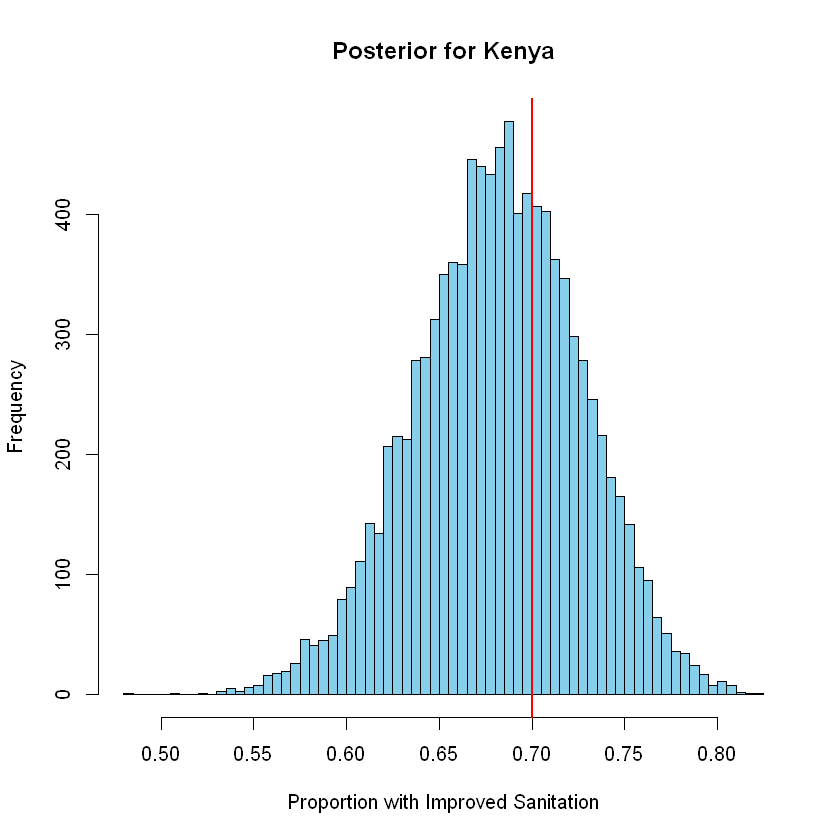

In [8]:
#Step 5 – Visualize a Country's Posterior

samples <- rbeta(10000, data$Post_Alpha[1], data$Post_Beta[1])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[1]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)


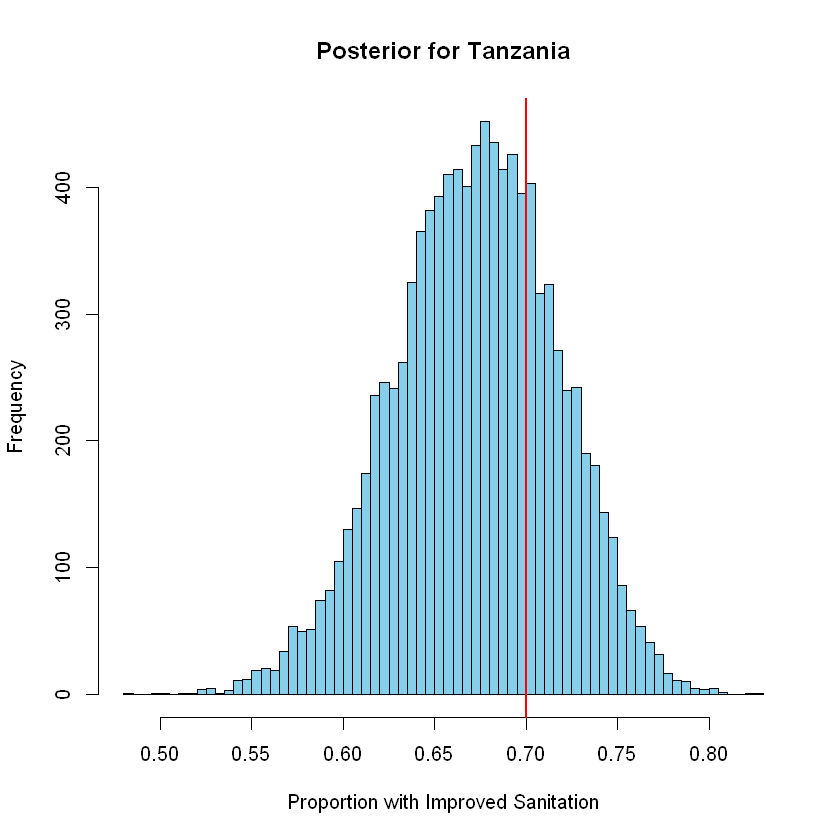

In [9]:
#Step 5 – Visualize a Country's Posterior

samples <- rbeta(10000, data$Post_Alpha[3], data$Post_Beta[3])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[3]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)


In [10]:
#Step 6 – Summary Table

summary_table <- data[c("Country", "Post_Improved_Sanitation", "Prob_Above_70")]
print(summary_table)
#This gives a readable overview of which countries showed strong improvement.

      Country Post_Improved_Sanitation Prob_Above_70
1       Kenya                       70        0.3457
2      Uganda                       69        0.2750
3    Tanzania                       69        0.2775
4      Rwanda                       75        0.7426
5    Ethiopia                       65        0.0771
6       Nepal                       67        0.1568
7  Bangladesh                       71        0.4322
8    Cambodia                       75        0.7430
9       Haiti                       70        0.3567
10  Guatemala                       68        0.2113


In [15]:
#Step 7 – Try These Modifications
#Change the prior to Beta(1, 1) or Beta(10, 10) – what happens?

alpha_prior_2 <- 5
beta_prior_2 <- 10

In [16]:
# Recalculate probability with new prior
set.seed(42)
data$Prob_Above_70_3 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha_3[i], data$Post_Beta_3[i])
  mean(samples > 0.7)
})

In [17]:
#printing the comparison
summary_table_2 <- data[, c("Country", "Post_Improved_Sanitation", 
                             "Prob_Above_70", "Prob_Above_70_3")]
print(summary_table_2)

      Country Post_Improved_Sanitation Prob_Above_70 Prob_Above_70_3
1       Kenya                       70        0.3457          0.0001
2      Uganda                       69        0.2750          0.0000
3    Tanzania                       69        0.2775          0.0025
4      Rwanda                       75        0.7426          0.0065
5    Ethiopia                       65        0.0771          0.0000
6       Nepal                       67        0.1568          0.0000
7  Bangladesh                       71        0.4322          0.0000
8    Cambodia                       75        0.7430          0.0000
9       Haiti                       70        0.3567          0.0001
10  Guatemala                       68        0.2113          0.0000


In [18]:
# Pre-intervention probability
set.seed(42)
data$Prob_Above_70_Pre <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha_2[i], data$Post_Beta_2[i])
  mean(samples > 0.7)
})

# Final comparison table
comparison <- data[, c("Country", 
                        "Prob_Above_70_Pre",   # before
                        "Prob_Above_70")]       # after
comparison$Improved <- comparison$Prob_Above_70 > comparison$Prob_Above_70_Pre

#Tells you per country whether the intervention actually worked 

print(comparison)

      Country Prob_Above_70_Pre Prob_Above_70 Improved
1       Kenya            0.0004        0.3457     TRUE
2      Uganda            0.0001        0.2750     TRUE
3    Tanzania            0.0137        0.2775     TRUE
4      Rwanda            0.0337        0.7426     TRUE
5    Ethiopia            0.0000        0.0771     TRUE
6       Nepal            0.0001        0.1568     TRUE
7  Bangladesh            0.0000        0.4322     TRUE
8    Cambodia            0.0000        0.7430     TRUE
9       Haiti            0.0009        0.3567     TRUE
10  Guatemala            0.0000        0.2113     TRUE


In [19]:
#Calculating expected improvement
#Posterior Mean = Alpha / (Alpha + Beta)
data$Pre_Mean <- data$Post_Alpha_2 / (data$Post_Alpha_2 + data$Post_Beta_2)
print(data$Pre_Mean)

 [1] 0.5545455 0.5272727 0.6000000 0.6181818 0.4727273 0.5272727 0.5363636
 [8] 0.4909091 0.5545455 0.5181818


In [20]:
data$Post_Mean <- data$Post_Alpha / (data$Post_Alpha + data$Post_Beta)
print(data$Post_Mean)

 [1] 0.6521739 0.6434783 0.6434783 0.6956522 0.6086957 0.6260870 0.6608696
 [8] 0.6956522 0.6521739 0.6347826


In [21]:
data$Expected_Improvement <- data$Post_Mean - data$Pre_Mean

# Print the result
improvement_table <- data[, c("Country", "Pre_Mean", "Post_Mean", "Expected_Improvement")]
print(improvement_table)

      Country  Pre_Mean Post_Mean Expected_Improvement
1       Kenya 0.5545455 0.6521739           0.09762846
2      Uganda 0.5272727 0.6434783           0.11620553
3    Tanzania 0.6000000 0.6434783           0.04347826
4      Rwanda 0.6181818 0.6956522           0.07747036
5    Ethiopia 0.4727273 0.6086957           0.13596838
6       Nepal 0.5272727 0.6260870           0.09881423
7  Bangladesh 0.5363636 0.6608696           0.12450593
8    Cambodia 0.4909091 0.6956522           0.20474308
9       Haiti 0.5545455 0.6521739           0.09762846
10  Guatemala 0.5181818 0.6347826           0.11660079
